In [14]:
import pandas as pd
import os
from glob import glob
import numpy as np
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from dgl.nn.pytorch import SAGEConv

def load_data(input_folder, num_of_nodes):
    """Load phylogenetic graph data with self-loops."""
    node_files = glob(os.path.join(input_folder, "*_node.csv"))
    print(f"Found {len(node_files)} node files")

    all_nodes = pd.concat([pd.read_csv(f) for f in node_files], ignore_index=True)
    node_counts = all_nodes.groupby('graph_id').size()
    valid_graph_ids = [gid for gid in node_counts.index if node_counts[gid] == num_of_nodes]
    print(f"Valid graphs with {num_of_nodes} nodes: {len(valid_graph_ids)}")

    dgl_graphs = []
    for graph_id in valid_graph_ids:
        node_df = all_nodes[all_nodes['graph_id'] == graph_id].sort_values('node').reset_index(drop=True)
        num_nodes = len(node_df)
        
        g = dgl.graph((torch.arange(num_nodes), torch.arange(num_nodes)))
        
        for col in node_df.columns:
            if col not in ['graph_id', 'node']:
                g.ndata[col] = torch.tensor(node_df[col].values, dtype=torch.float32)
        
        g.graph_id = graph_id
        dgl_graphs.append(g)

    print(f"Converted {len(dgl_graphs)} graphs to DGL format")
    return dgl_graphs

def select_features_and_labels(graphs, feature_names, label_name):
    """Extract selected features and labels from graphs."""
    for g in graphs:
        features = torch.stack([g.ndata[name] for name in feature_names], dim=1)
        g.ndata['feat'] = features
        g.ndata['label'] = g.ndata[label_name]
    
    in_dim = len(feature_names)
    print(f"\nFeatures: {feature_names} (dim={in_dim})")
    print(f"Label: {label_name}")
    return graphs, in_dim

# Load data
input_folder = '/Users/lukelyu/Desktop/epidata/100_10_new/'
dgl_graphs = load_data(input_folder, num_of_nodes=10)

# Feature and label selection
selected_features = ['Initial_Population', 'Epidemic_Peak', 'Peak_Timing', 'Accumulated_Infections']
selected_label = 'Source_Sink_Score'
dgl_graphs, in_dim = select_features_and_labels(dgl_graphs, selected_features, selected_label)

# Train/val/test split (70/15/15)
torch.manual_seed(42)
train_graphs, temp_graphs = train_test_split(dgl_graphs, test_size=0.3, random_state=42)
val_graphs, test_graphs = train_test_split(temp_graphs, test_size=0.5, random_state=42)

print(f"Data split - Train: {len(train_graphs)}, Val: {len(val_graphs)}, Test: {len(test_graphs)}")

# ============================================================
# Z-score normalization for ALL features
# ============================================================
print(f"\nStandardizing all {len(selected_features)} features using Z-score normalization:")

for feature_idx, feature_name in enumerate(selected_features):
    # Calculate mean and std from training data only
    all_feature_train = torch.cat([g.ndata['feat'][:, feature_idx] for g in train_graphs])
    feature_mean = all_feature_train.mean()
    feature_std = all_feature_train.std()
    
    print(f"  {feature_name}: Mean={feature_mean:.4f}, Std={feature_std:.4f}")
    
    # Apply normalization to all splits
    for g in train_graphs + val_graphs + test_graphs:
        g.ndata['feat'][:, feature_idx] = (g.ndata['feat'][:, feature_idx] - feature_mean) / feature_std

print("\nAll features have been standardized using Z-score normalization")
# ============================================================

Found 50 node files
Valid graphs with 10 nodes: 500
Converted 500 graphs to DGL format

Features: ['Initial_Population', 'Epidemic_Peak', 'Peak_Timing', 'Accumulated_Infections'] (dim=4)
Label: Source_Sink_Score
Data split - Train: 350, Val: 75, Test: 75

Standardizing all 4 features using Z-score normalization:
  Initial_Population: Mean=5482.8291, Std=2606.5315
  Epidemic_Peak: Mean=2058.5991, Std=1064.8995
  Peak_Timing: Mean=140.8354, Std=38.9437
  Accumulated_Infections: Mean=5406.4653, Std=2705.0078

All features have been standardized using Z-score normalization


For troubleshooting, I’m planning to adjust things in stages:

Node features: add timing and magnitude of the epidemic peak as node feature, and be careful with normalization so the scale is meaningful.

Graph structure: since an MLP is essentially a GNN with only self-loops, and the MLP works, I’ll follow Zewen’s suggestion: start training GCN/GraphSAGE on a degenerated (self-loop-only) graph and then gradually reintroduce real edges to see how graph structure influences performance.

Training targets: switch to a simpler target first, such as estimating node-specific R0

In [15]:
class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super(GraphSAGE, self).__init__()
        self.conv = SAGEConv(in_dim, hidden_dim, aggregator_type='mean')
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, node_feat):
        h = self.conv(g, node_feat)
        return self.classifier(h).squeeze(-1)


class MLP(nn.Module):
    def __init__(self, in_dim):
        super(MLP, self).__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Linear(8, 1)
        )
    
    def forward(self, g, node_feat):
        return self.layers(node_feat).squeeze(-1)

In [16]:
def train_epoch(model, graphs, optimizer, criterion):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    total_samples = 0
    
    for g in graphs:
        optimizer.zero_grad()
        pred = model(g, g.ndata['feat'])
        loss = criterion(pred, g.ndata['label'])
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * g.num_nodes()
        total_samples += g.num_nodes()
    
    return total_loss / total_samples


def evaluate(model, graphs, criterion):
    """Evaluate model."""
    model.eval()
    total_loss = 0
    total_samples = 0
    
    with torch.no_grad():
        for g in graphs:
            pred = model(g, g.ndata['feat'])
            loss = criterion(pred, g.ndata['label'])
            total_loss += loss.item() * g.num_nodes()
            total_samples += g.num_nodes()
    
    return total_loss / total_samples


# Train GraphSAGE
print("=" * 60)
print("Training GraphSAGE Model")
print("=" * 60)
model_gnn = GraphSAGE(in_dim=in_dim, hidden_dim=32)
optimizer_gnn = torch.optim.Adam(model_gnn.parameters(), lr=0.001)
criterion = nn.MSELoss()

print(f"Model: GraphSAGE(in_dim={in_dim}, hidden_dim=32)")
print(f"Parameters: {sum(p.numel() for p in model_gnn.parameters())}\n")

num_epochs = 100
best_val_loss_gnn = float('inf')
patience = 20
patience_counter = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(model_gnn, train_graphs, optimizer_gnn, criterion)
    val_loss = evaluate(model_gnn, val_graphs, criterion)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss_gnn:
        best_val_loss_gnn = val_loss
        patience_counter = 0
        best_model_state_gnn = model_gnn.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_gnn.load_state_dict(best_model_state_gnn)
test_loss_gnn = evaluate(model_gnn, test_graphs, criterion)

print(f"\nBest Val Loss: {best_val_loss_gnn:.6f}")
print(f"Test Loss: {test_loss_gnn:.6f}")


# Train MLP
print("\n" + "=" * 60)
print("Training MLP Model")
print("=" * 60)
model_mlp = MLP(in_dim=in_dim)
optimizer_mlp = torch.optim.Adam(model_mlp.parameters(), lr=0.001)

print(f"Model: MLP(in_dim={in_dim} -> 32 -> 8 -> 1)")
print(f"Parameters: {sum(p.numel() for p in model_mlp.parameters())}\n")

best_val_loss_mlp = float('inf')
patience_counter = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(model_mlp, train_graphs, optimizer_mlp, criterion)
    val_loss = evaluate(model_mlp, val_graphs, criterion)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{num_epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
    
    if val_loss < best_val_loss_mlp:
        best_val_loss_mlp = val_loss
        patience_counter = 0
        best_model_state_mlp = model_mlp.state_dict().copy()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

model_mlp.load_state_dict(best_model_state_mlp)
test_loss_mlp = evaluate(model_mlp, test_graphs, criterion)

print(f"\nBest Val Loss: {best_val_loss_mlp:.6f}")
print(f"Test Loss: {test_loss_mlp:.6f}")

print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"GraphSAGE - Test Loss: {test_loss_gnn:.6f}")
print(f"MLP       - Test Loss: {test_loss_mlp:.6f}")

Training GraphSAGE Model
Model: GraphSAGE(in_dim=4, hidden_dim=32)
Parameters: 561

Epoch  10/100 | Train Loss: 0.020695 | Val Loss: 0.022853
Epoch  20/100 | Train Loss: 0.019642 | Val Loss: 0.021890
Epoch  30/100 | Train Loss: 0.019525 | Val Loss: 0.021782
Epoch  40/100 | Train Loss: 0.019453 | Val Loss: 0.021889
Early stopping at epoch 44

Best Val Loss: 0.021717
Test Loss: 0.019134

Training MLP Model
Model: MLP(in_dim=4 -> 32 -> 8 -> 1)
Parameters: 433

Epoch  10/100 | Train Loss: 0.019305 | Val Loss: 0.021508
Epoch  20/100 | Train Loss: 0.018220 | Val Loss: 0.020440
Epoch  30/100 | Train Loss: 0.017815 | Val Loss: 0.019972
Epoch  40/100 | Train Loss: 0.017519 | Val Loss: 0.019799
Epoch  50/100 | Train Loss: 0.017240 | Val Loss: 0.019527
Epoch  60/100 | Train Loss: 0.017003 | Val Loss: 0.019350
Epoch  70/100 | Train Loss: 0.016803 | Val Loss: 0.019067
Epoch  80/100 | Train Loss: 0.016612 | Val Loss: 0.018782
Epoch  90/100 | Train Loss: 0.016479 | Val Loss: 0.018709
Epoch 100/100 | 

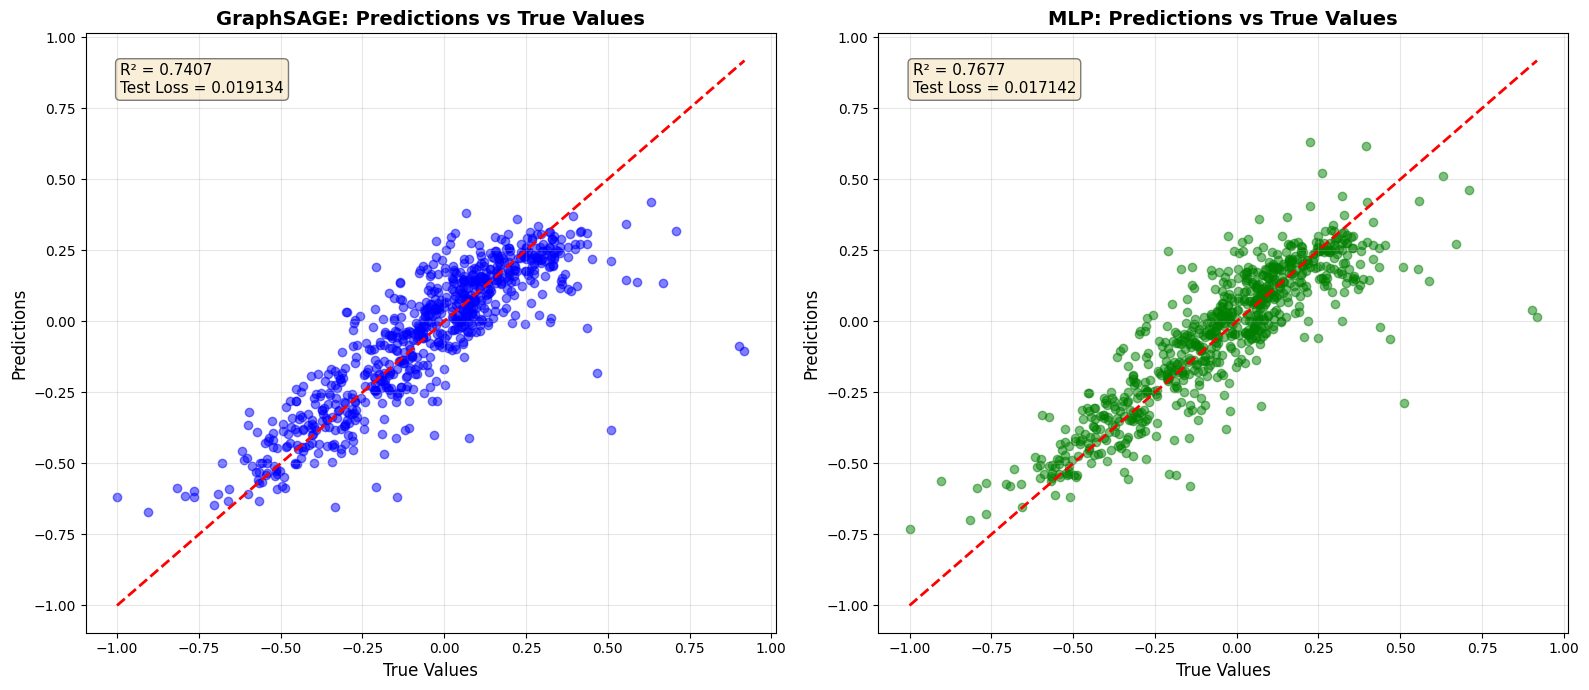

Model Comparison on Test Set
GraphSAGE - R² Score: 0.7407, Test Loss: 0.019134
MLP       - R² Score: 0.7677, Test Loss: 0.017142


In [17]:
# Compare predictions from both models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Get predictions from GraphSAGE
model_gnn.eval()
gnn_preds = []
all_labels = []

with torch.no_grad():
    for g in test_graphs:
        pred = model_gnn(g, g.ndata['feat'])
        gnn_preds.extend(pred.cpu().numpy())
        all_labels.extend(g.ndata['label'].cpu().numpy())

gnn_preds = np.array(gnn_preds)
all_labels = np.array(all_labels)

# Get predictions from MLP
model_mlp.eval()
mlp_preds = []

with torch.no_grad():
    for g in test_graphs:
        pred = model_mlp(g, g.ndata['feat'])
        mlp_preds.extend(pred.cpu().numpy())

mlp_preds = np.array(mlp_preds)

# Create side-by-side comparison plots
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# GraphSAGE plot
axes[0].scatter(all_labels, gnn_preds, alpha=0.5, color='blue')
axes[0].plot([all_labels.min(), all_labels.max()], 
             [all_labels.min(), all_labels.max()], 'r--', lw=2)
axes[0].set_xlabel('True Values', fontsize=12)
axes[0].set_ylabel('Predictions', fontsize=12)
axes[0].set_title('GraphSAGE: Predictions vs True Values', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
gnn_r2 = r2_score(all_labels, gnn_preds)
axes[0].text(0.05, 0.95, f'R² = {gnn_r2:.4f}\nTest Loss = {test_loss_gnn:.6f}', 
             transform=axes[0].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# MLP plot
axes[1].scatter(all_labels, mlp_preds, alpha=0.5, color='green')
axes[1].plot([all_labels.min(), all_labels.max()], 
             [all_labels.min(), all_labels.max()], 'r--', lw=2)
axes[1].set_xlabel('True Values', fontsize=12)
axes[1].set_ylabel('Predictions', fontsize=12)
axes[1].set_title('MLP: Predictions vs True Values', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
mlp_r2 = r2_score(all_labels, mlp_preds)
axes[1].text(0.05, 0.95, f'R² = {mlp_r2:.4f}\nTest Loss = {test_loss_mlp:.6f}', 
             transform=axes[1].transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print comparison summary
print("=" * 60)
print("Model Comparison on Test Set")
print("=" * 60)
print(f"GraphSAGE - R² Score: {gnn_r2:.4f}, Test Loss: {test_loss_gnn:.6f}")
print(f"MLP       - R² Score: {mlp_r2:.4f}, Test Loss: {test_loss_mlp:.6f}")